In [1]:
# Imports and Configurations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS 
from statsmodels.tools import add_constant
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

np.random.seed(42)

In [2]:
# Laading saved outputs from Notebook 2
sharpe_data = pd.read_csv('sharpe_data.csv', index_col=0, parse_dates=True)

cluster_k2 = pd.read_csv('cluster_assignments_sharpe_k2.csv')
cluster_k4 = pd.read_csv('cluster_assignments_sharpe_k4.csv')
cluster_k7 = pd.read_csv('cluster_assignments_sharpe_k7.csv')

print('Sharpe data shape:', sharpe_data.shape)
print('Date range:', sharpe_data.index[0].date(), 'to', sharpe_data.index[-1].date())
print('\nCluster assignment shapes:')
print(f' k=2: {cluster_k2.shape}, k=4:  {cluster_k4.shape}, k=7 = {cluster_k7.shape}')
print('\nSample cluster assignments (k=4, first 5 rows):')
print(cluster_k4.head())

Sharpe data shape: (470, 77)
Date range: 2014-12-31 to 2023-12-27

Cluster assignment shapes:
 k=2: (77, 3), k=4:  (77, 3), k=7 = (77, 3)

Sample cluster assignments (k=4, first 5 rows):
  Ticker  Cluster       Sector
0   AAPL        2   Technology
1   ADBE        1   Technology
2    ADI        1   Technology
3    ADP        4  Industrials
4   ALGN        3   Healthcare


In [3]:
# Redownloading price data
import yfinance as yf

tickers = sharpe_data.columns.tolist()

print(f'Re-downloading price data for {len(tickers)} stocks...')
print('Using same configuration as Notebook 2: weekly Wednesday, 2014-2023\n')

raw = yf.download(
    tickers,
    start='2014-01-01',
    end='2024-01-01',
    interval='1wk', 
    auto_adjust=True,
    progress=True
)

price_data = raw['Close']
price_data = price_data.resample('W-WED').last()
price_data = price_data.dropna(how='all')
price_data = price_data[tickers]
price_data = price_data.ffill().dropna(axis=1)

# Keeping only tickers present in both sharpe_data and price_data
common_tickers  = [t for t in tickers if t in price_data.columns]
price_data = price_data[common_tickers]

print(f'\nPrice data shape: {price_data.shape}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Tickers retained: {len(common_tickers)}')

print(sharpe_data.columns.tolist() == common_tickers)

Re-downloading price data for 77 stocks...
Using same configuration as Notebook 2: weekly Wednesday, 2014-2023



[*********************100%***********************]  77 of 77 completed



Price data shape: (522, 77)
Date range: 2014-01-01 to 2023-12-27
Tickers retained: 77
True


In [4]:
# Building cluster lookup

cluster_map = {}

for k, df in [(2, cluster_k2), (4, cluster_k4), (7, cluster_k7)]:
    cluster_map[k] = {}
    for cluster_num in sorted(df['Cluster'].unique()):
        tickers_in_cluster = df[df['Cluster'] == cluster_num]['Ticker'].tolist()
        cluster_map[k][cluster_num] = tickers_in_cluster

for k in [2, 4, 7]:
    print(f'\nk={k}:')
    for cluster_num, tickers in cluster_map[k].items():
        print(f' Cluster {cluster_num} ({len(tickers)} stocks): {', '.join(tickers)}')


k=2:
 Cluster 1 (38 stocks): ADBE, ADI, AMAT, AMD, AMZN, ASML, BKNG, BKR, CCEP, CDNS, CPRT, FANG, FAST, GOOG, GOOGL, IDXX, INTU, KLAC, LIN, LRCX, MCHP, MELI, META, MRVL, MSFT, MU, NFLX, NVDA, ODFL, ON, PCAR, QCOM, SNPS, TSLA, VRSK, VRTX, WBD, WDAY
 Cluster 2 (39 stocks): AAPL, ADP, ALGN, AMGN, AVGO, AZN, BIIB, CDW, COST, CSCO, CSGP, CTAS, CTSH, DLTR, DXCM, EA, ENPH, EXC, FTNT, GILD, HON, ILMN, ISRG, KDP, MAR, MDLZ, MNST, MTCH, ORLY, PANW, PAYX, PEP, REGN, ROST, SBUX, SIRI, SMCI, TXN, XEL

k=4:
 Cluster 1 (38 stocks): ADBE, ADI, AMAT, AMD, AMZN, ASML, BKNG, BKR, CCEP, CDNS, CPRT, FANG, FAST, GOOG, GOOGL, IDXX, INTU, KLAC, LIN, LRCX, MCHP, MELI, META, MRVL, MSFT, MU, NFLX, NVDA, ODFL, ON, PCAR, QCOM, SNPS, TSLA, VRSK, VRTX, WBD, WDAY
 Cluster 2 (11 stocks): AAPL, AVGO, COST, CTSH, GILD, MAR, MNST, ORLY, PANW, REGN, SMCI
 Cluster 3 (11 stocks): ALGN, AZN, CSGP, DXCM, ENPH, HON, ISRG, MDLZ, MTCH, SBUX, SIRI
 Cluster 4 (17 stocks): ADP, AMGN, BIIB, CDW, CSCO, CTAS, DLTR, EA, EXC, FTNT, ILM

In [5]:
def run_adf(series, name=''):
    """
    Runs ADF test on a price series and returns a results dictionary. 
    H0: the series has a unit root (is non-stationary, I(1))
    We want to fail to reject H0 here - I(1) is the precondition for cointegration.
    """
    result = adfuller(series.dropna(), autolag='AIC')
    return  {
        'Ticker': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'Lags Used': result[2],
        'I(1)': 'Yes' if result[1] > 0.05 else 'No'
    }

# Running ADF on every stock's price series
print('Running ADF unit root tests on all 77 price series...')
print('H0: series has a unit root (non-stationary)')
print('We want p > 0.05 to confirm I(1) - the cointegration precondition\n')

adf_results = []
for ticker in price_data.columns:
    adf_results.append(run_adf(price_data[ticker], name=ticker))

adf_df = pd.DataFrame(adf_results).set_index('Ticker')

# Summarizing ADF Results
i1_count = (adf_df['I(1)'] == 'Yes').sum()
i0_count = (adf_df['I(1)'] == 'No').sum()

print(f'Results: {i1_count} stocks confirmed I(1), {i0_count} stocks flagged as I(0)\n')

print('Stocks flagged as potential I(0) (Stationary - inspect carefully):')
print(adf_df[adf_df['I(1)'] == 'No'][['ADF Statistic', 'p-value']])

print("\nFull ADF results:")
print(adf_df.sort_values('p-value', ascending=False))

Running ADF unit root tests on all 77 price series...
H0: series has a unit root (non-stationary)
We want p > 0.05 to confirm I(1) - the cointegration precondition

Results: 76 stocks confirmed I(1), 1 stocks flagged as I(0)

Stocks flagged as potential I(0) (Stationary - inspect carefully):
        ADF Statistic  p-value
Ticker                        
BIIB          -3.7026   0.0041

Full ADF results:
        ADF Statistic  p-value  Lags Used I(1)
Ticker                                        
AVGO           2.9582   1.0000          4  Yes
SNPS           3.0976   1.0000         14  Yes
KLAC           2.9532   1.0000         19  Yes
PANW           2.0974   0.9988         16  Yes
PCAR           1.9953   0.9987          1  Yes
...               ...      ...        ...  ...
EA            -2.0993   0.2448          0  Yes
GILD          -2.4119   0.1384          0  Yes
CTSH          -2.4597   0.1256          0  Yes
WBD           -2.5763   0.0980          4  Yes
BIIB          -3.7026   0.0041 

In [6]:
# Running Engle-Granger Cointegration tests on all pairs within each cluster
def test_cointegration(s1, s2, ticker1, ticker2):
    """
    Runs Engle-Granger cointegration test on two price series.
    H0: no cointegration exists between the two series.
    We want to reject the H0 here - low p-value means cointegrated.
    """
    # Aligning series on shared dates
    combined = pd.concat([s1, s2], axis=1).dropna()
    s1_clean = combined.iloc[:,0]
    s2_clean = combined.iloc[:,1]

    score, pvalue,  _ = coint(s1_clean, s2_clean)
    pvalue = float(pvalue)
    score = float(score)
    assert isinstance(pvalue, float), f'pvalue is {type(pvalue)}'
    assert pvalue >= 0 and pvalue <= 1, f'pvalue out of range: {pvalue}'

    pvalue_rounded = round(float(pvalue), 4)
    score_rounded = round(float(score), 4)


    return {
        'Ticker 1': ticker1, 
        'Ticker 2': ticker2, 
        'Score': score_rounded,
        'p-value': pvalue_rounded,
        'Cointegrated': 'Yes' if pvalue < 0.05 else 'No'
    }

# Running Tests across all k values and clusters
all_coint_results = {}

for k in [2,4,7]:
    all_coint_results[k] = {}
    total_pairs = 0
    total_cointegrated = 0

    print(f'\n{'='*65}')
    print(f'k={k} INTRA-CLUSTER COINTEGRATION RESULTS:')
    print(f'\n{'='*65}')

    for cluster_num, tickers in cluster_map[k].items():
        
        # Filtering for tickers present in price data
        valid_tickers = [t for t in tickers if t in price_data.columns]

        # Generating all unique pairs
        pairs = list(combinations(valid_tickers, 2))
        results = []

        for t1, t2 in pairs:
            result = test_cointegration(
                price_data[t1], price_data[t2], t1, t2
            )
            results.append(result)

        # Converting to DataFrames and sorting by p-vaue
        results_df = pd.DataFrame(results).sort_values('p-value')
        all_coint_results[k][cluster_num] = results_df

        # Counting cointegrated pairs
        n_coint = (results_df['Cointegrated'] == 'Yes').sum()
        total_pairs += len(pairs)
        total_cointegrated += n_coint

        print(f"\nCluster {cluster_num} ({len(valid_tickers)} stocks,"
              f" {len(pairs)} pairs): {n_coint} cointegrated")

        # Printing top 5 pairs by p-value
        print(f" Top 5 pairs by p-value:")
        top5 = results_df.head(5).reset_index(drop=True)
        for i in range(len(top5)):
            row = top5.iloc[i]
            print(f"  {row['Ticker 1']}/{row['Ticker 2']}: "
                  f"p={row['p-value']:.4f} -> {row['Cointegrated']}")

    print(f"\nk={k} Summary: {total_cointegrated} cointegrated"
          f"  pairs out of {total_pairs} total")


k=2 INTRA-CLUSTER COINTEGRATION RESULTS:


Cluster 1 (38 stocks, 703 pairs): 76 cointegrated
 Top 5 pairs by p-value:
  KLAC/ODFL: p=0.0000 -> Yes
  FAST/MSFT: p=0.0000 -> Yes
  ODFL/SNPS: p=0.0000 -> Yes
  KLAC/SNPS: p=0.0000 -> Yes
  CDNS/SNPS: p=0.0000 -> Yes

Cluster 2 (39 stocks, 741 pairs): 88 cointegrated
 Top 5 pairs by p-value:
  ENPH/FTNT: p=0.0002 -> Yes
  BIIB/DLTR: p=0.0006 -> Yes
  BIIB/EXC: p=0.0009 -> Yes
  BIIB/XEL: p=0.0009 -> Yes
  AMGN/CTAS: p=0.0009 -> Yes

k=2 Summary: 164 cointegrated  pairs out of 1444 total

k=4 INTRA-CLUSTER COINTEGRATION RESULTS:


Cluster 1 (38 stocks, 703 pairs): 76 cointegrated
 Top 5 pairs by p-value:
  KLAC/ODFL: p=0.0000 -> Yes
  FAST/MSFT: p=0.0000 -> Yes
  ODFL/SNPS: p=0.0000 -> Yes
  KLAC/SNPS: p=0.0000 -> Yes
  CDNS/SNPS: p=0.0000 -> Yes

Cluster 2 (11 stocks, 55 pairs): 2 cointegrated
 Top 5 pairs by p-value:
  AAPL/COST: p=0.0368 -> Yes
  AAPL/MNST: p=0.0424 -> Yes
  MNST/ORLY: p=0.0742 -> No
  COST/MNST: p=0.0951 -> No
  CTSH/MN

In [12]:
# Benjamini-Hochberg correction for multiple testing
from statsmodels.stats.multitest import multipletests

def apply_bh_correction(results_df, alpha=0.05):
    """
    Applies Benjamini-Hochberg False Discovery Rate correction.
    Adjusts p-values upward to account for running many simultaneous tests.
    Returns the DataFrame with an additional column: 'BH_Cointegrated'
    """
    pvalues = results_df['p-value'].values
    reject, pvals_corrected, _, _ = multipletests(pvalues, alpha=alpha, method='fdr_bh')

    results_df = results_df.copy()
    results_df['BH_p-value'] = np.round(pvals_corrected, 4)
    results_df['BH_Cointegrated'] = ['Yes' if r else 'No' for r in reject]

    return results_df

# Applying correction across all k values and clusters
print('Applying Benjamini-Hochberg correction across all k values...\n')

all_coint_corrected = {}

for k in [2,4,7]:
    all_coint_corrected[k] = {}
    total_original = 0
    total_corrected = 0

    print(f'\n{'='*65}')
    print(f'k={k} AFTER BENJAMINI-HOCHBERG CORRECTION')
    print(f'\n{'='*65}')

    for cluster_num, results_df in all_coint_results[k].items():
        corrected_df = apply_bh_correction(results_df)
        all_coint_corrected[k][cluster_num] = corrected_df

        n_original = (corrected_df['Cointegrated'] == 'Yes').sum()
        n_corrected = (corrected_df['BH_Cointegrated'] == 'Yes').sum()
        total_original += n_original
        total_corrected += n_corrected

        print(f"\nCluster {cluster_num}: {n_original} -> {n_corrected}"
              f" cointegrated pairs after correction")

        # Printing surviving pairs
        survivors = corrected_df[corrected_df['BH_Cointegrated'] == 'Yes'].reset_index(drop=True)
        if len(survivors) > 0:
            for i in range(len(survivors)):
                row = survivors.iloc[i]
                print(f"  {row['Ticker 1']}/{row['Ticker 2']}: "
                      f"p={row['p-value']:.4f} BH_p={row['BH_p-value']:.4f}")
        else:
            print("  No pairs survived correction")

    print(f"\k={k} Summary: {total_original} -> {total_corrected} "
          f"pairs after BH correction")

# Building final candidates list
print(f'\n{'='*65}')
print(f'FINAL CANDIDATE PAIRS (surviving BH correction at all k values)')
print(f'\n{'='*65}')

# Collecting all surivor pairs across all k values
candidate_pairs = set()

for k in [2,4,7]:
    for cluster_num, corrected_df in all_coint_corrected[k].items():
        survivors = corrected_df[corrected_df['BH_Cointegrated'] == 'Yes']
        for i in range(len(survivors)):
            row = survivors.reset_index(drop=True).iloc[i]
            pair = tuple(sorted([row['Ticker 1'], row['Ticker 2']]))
            candidate_pairs.add(pair)

print(f"\nUnique pairs surviving BH correction across any k value: "
      f"{len(candidate_pairs)}")
print(f"\nAll surviving pairs:")
for pair in sorted(candidate_pairs):
    print(f"  {pair[0]}/{pair[1]}")
    

Applying Benjamini-Hochberg correction across all k values...


k=2 AFTER BENJAMINI-HOCHBERG CORRECTION


Cluster 1: 76 -> 8 cointegrated pairs after correction
  KLAC/ODFL: p=0.0000 BH_p=0.0000
  FAST/MSFT: p=0.0000 BH_p=0.0000
  ODFL/SNPS: p=0.0000 BH_p=0.0000
  KLAC/SNPS: p=0.0000 BH_p=0.0000
  CDNS/SNPS: p=0.0000 BH_p=0.0000
  CDNS/KLAC: p=0.0001 BH_p=0.0117
  QCOM/TSLA: p=0.0003 BH_p=0.0301
  GOOG/GOOGL: p=0.0004 BH_p=0.0352

Cluster 2: 88 -> 0 cointegrated pairs after correction
  No pairs survived correction
\k=2 Summary: 164 -> 8 pairs after BH correction

k=4 AFTER BENJAMINI-HOCHBERG CORRECTION


Cluster 1: 76 -> 8 cointegrated pairs after correction
  KLAC/ODFL: p=0.0000 BH_p=0.0000
  FAST/MSFT: p=0.0000 BH_p=0.0000
  ODFL/SNPS: p=0.0000 BH_p=0.0000
  KLAC/SNPS: p=0.0000 BH_p=0.0000
  CDNS/SNPS: p=0.0000 BH_p=0.0000
  CDNS/KLAC: p=0.0001 BH_p=0.0117
  QCOM/TSLA: p=0.0003 BH_p=0.0301
  GOOG/GOOGL: p=0.0004 BH_p=0.0352

Cluster 2: 2 -> 0 cointegrated pairs after correction
  No

In [15]:
# Defining the pairs we will build spreads for

# Tier 1: Strongest Candidates (Survived BH at every k-value)
tier1_pairs = [
    ('CDNS', 'SNPS'),
    ('KLAC', 'ODFL'),
    ('KLAC', 'SNPS'),
    ('ODFL', 'SNPS'),
    ('CDNS', 'KLAC'),
]

# Tier 2: Survived BH at some k values, both legs confirmed I(1)
tier2_pairs = [
    ('FAST', 'MSFT'),
    ('QCOM', 'TSLA'),
    ('PAYX', 'PEP'),
    ('ADP', 'PEP'),
    ('AMGN', 'CTAS'),
    ('CDW', 'CTAS'),
    ('AMGN', 'CDW'),
]

all_pairs = tier1_pairs + tier2_pairs

print(f'Total pairs selected for spread construction: {len(all_pairs)}')
print(f' Teir 1: {len(tier1_pairs)}')
print(f' Teir 2: {len(tier2_pairs)}')

# Function to estimate hedge ratio and build spread

def build_spread(ticker1, ticker2, price_data):
    """
    Estimates the hedge ration between ticker1 and ticker2 using OLS regression.
    Spread = price1 - hedge_ratio * price2

    The hedge ratio tells you how many dollars of ticker2 to hold
    per dollar of ticker1 so the position is statistically neutral.
    """
    # Aligning price series on shared dates
    combined = pd.concat(
        [price_data[ticker1], price_data[ticker2]], axis=1
    ).dropna()
    combined.columns = [ticker1, ticker2]

    # OLS Regression: regress ticker1 on ticker2
    X = add_constant(combined[ticker2])
    model = OLS(combined[ticker1], X).fit()
    hedge_ratio = model.params[ticker2]
    intercept = model.params['const']

    # Constructing the spread
    spread = combined[ticker1] - hedge_ratio * combined[ticker2]

    return {
        'spread': spread,
        'hedge_ratio': round(float(hedge_ratio), 4),
        'intercept': round(float(intercept), 4),
        'r_squared': round(float(model.rsquared), 4),
        'ticker1': ticker1,
        'ticker2': ticker2,
        'prices': combined
    }

# Building spreads for all pairs
print(f'\nBuilding spreads and estimating hedge ratios...')
print(f'{'Pair':<15} {'Hedge Ratio':>12} {'Intercept':>12} {'R-Squared':>12}')
print('-'* 55)

spread_data = {}

for t1, t2 in all_pairs:
    result = build_spread(t1, t2, price_data)
    spread_data[f'{t1}/{t2}'] = result
    print(f'{t1}/{t2:<12} {result['hedge_ratio']:>12.4f}'
          f'{result['intercept']:>12.4f} {result['r_squared']:>12.4f}')

# Running ADF on each spread to confirm I(0)
print(f'\n{'='*55}')
print('ADF TEST ON SPREAD (confirming mean-reversion)')
print(f'\n{'='*55}')
print('We want p < 0.05 here - spread should be stationary I(0)\n')

spread_adf_results = []

for pair_name, data in spread_data.items():
    adf_result = adfuller(data['spread'].dropna(), autolag='AIC')
    pvalue = float(adf_result[1])
    stationary = 'Yes' if pvalue < 0.05 else 'No'

    spread_adf_results.append({
        'Pair': pair_name,
        'ADF Statistic': round(float(adf_result[0]), 4),
        'p-value': round(pvalue, 4),
        'Stationary I(0)': stationary
    })

    print(f'{pair_name:<15} ADF={adf_result[0]:>8.4f} '
          f'p={pvalue:.4f} Stationary: {stationary}')

spread_adf_df = pd.DataFrame(spread_adf_results).set_index('Pair')

n_stationary = (spread_adf_df['Stationary I(0)'] == 'Yes').sum()
print(f'\n{n_stationary} of {len(all_pairs)} spreads confirmed stationary')                                        

Total pairs selected for spread construction: 12
 Teir 1: 5
 Teir 2: 7

Building spreads and estimating hedge ratios...
Pair             Hedge Ratio    Intercept    R-Squared
-------------------------------------------------------
CDNS/SNPS               0.5252     -3.6712       0.9958
KLAC/ODFL               0.2431     -0.2807       0.9747
KLAC/SNPS               0.1036      0.2761       0.9829
ODFL/SNPS               0.4184      3.6079       0.9710
CDNS/KLAC               4.9793     -3.5308       0.9781
FAST/MSFT               0.0689      5.2237       0.9806
QCOM/TSLA               0.3127     46.5781       0.9008
PAYX/PEP                0.8269    -21.3336       0.9455
ADP/PEP                1.7047    -48.7956       0.9496
AMGN/CTAS               1.2371     90.6562       0.8945
CDW/CTAS               1.6031      6.1434       0.9682
AMGN/CDW                0.7554     87.4769       0.8852

ADF TEST ON SPREAD (confirming mean-reversion)

We want p < 0.05 here - spread should be stationar

Generating spread visualizations for all 12 pairs...


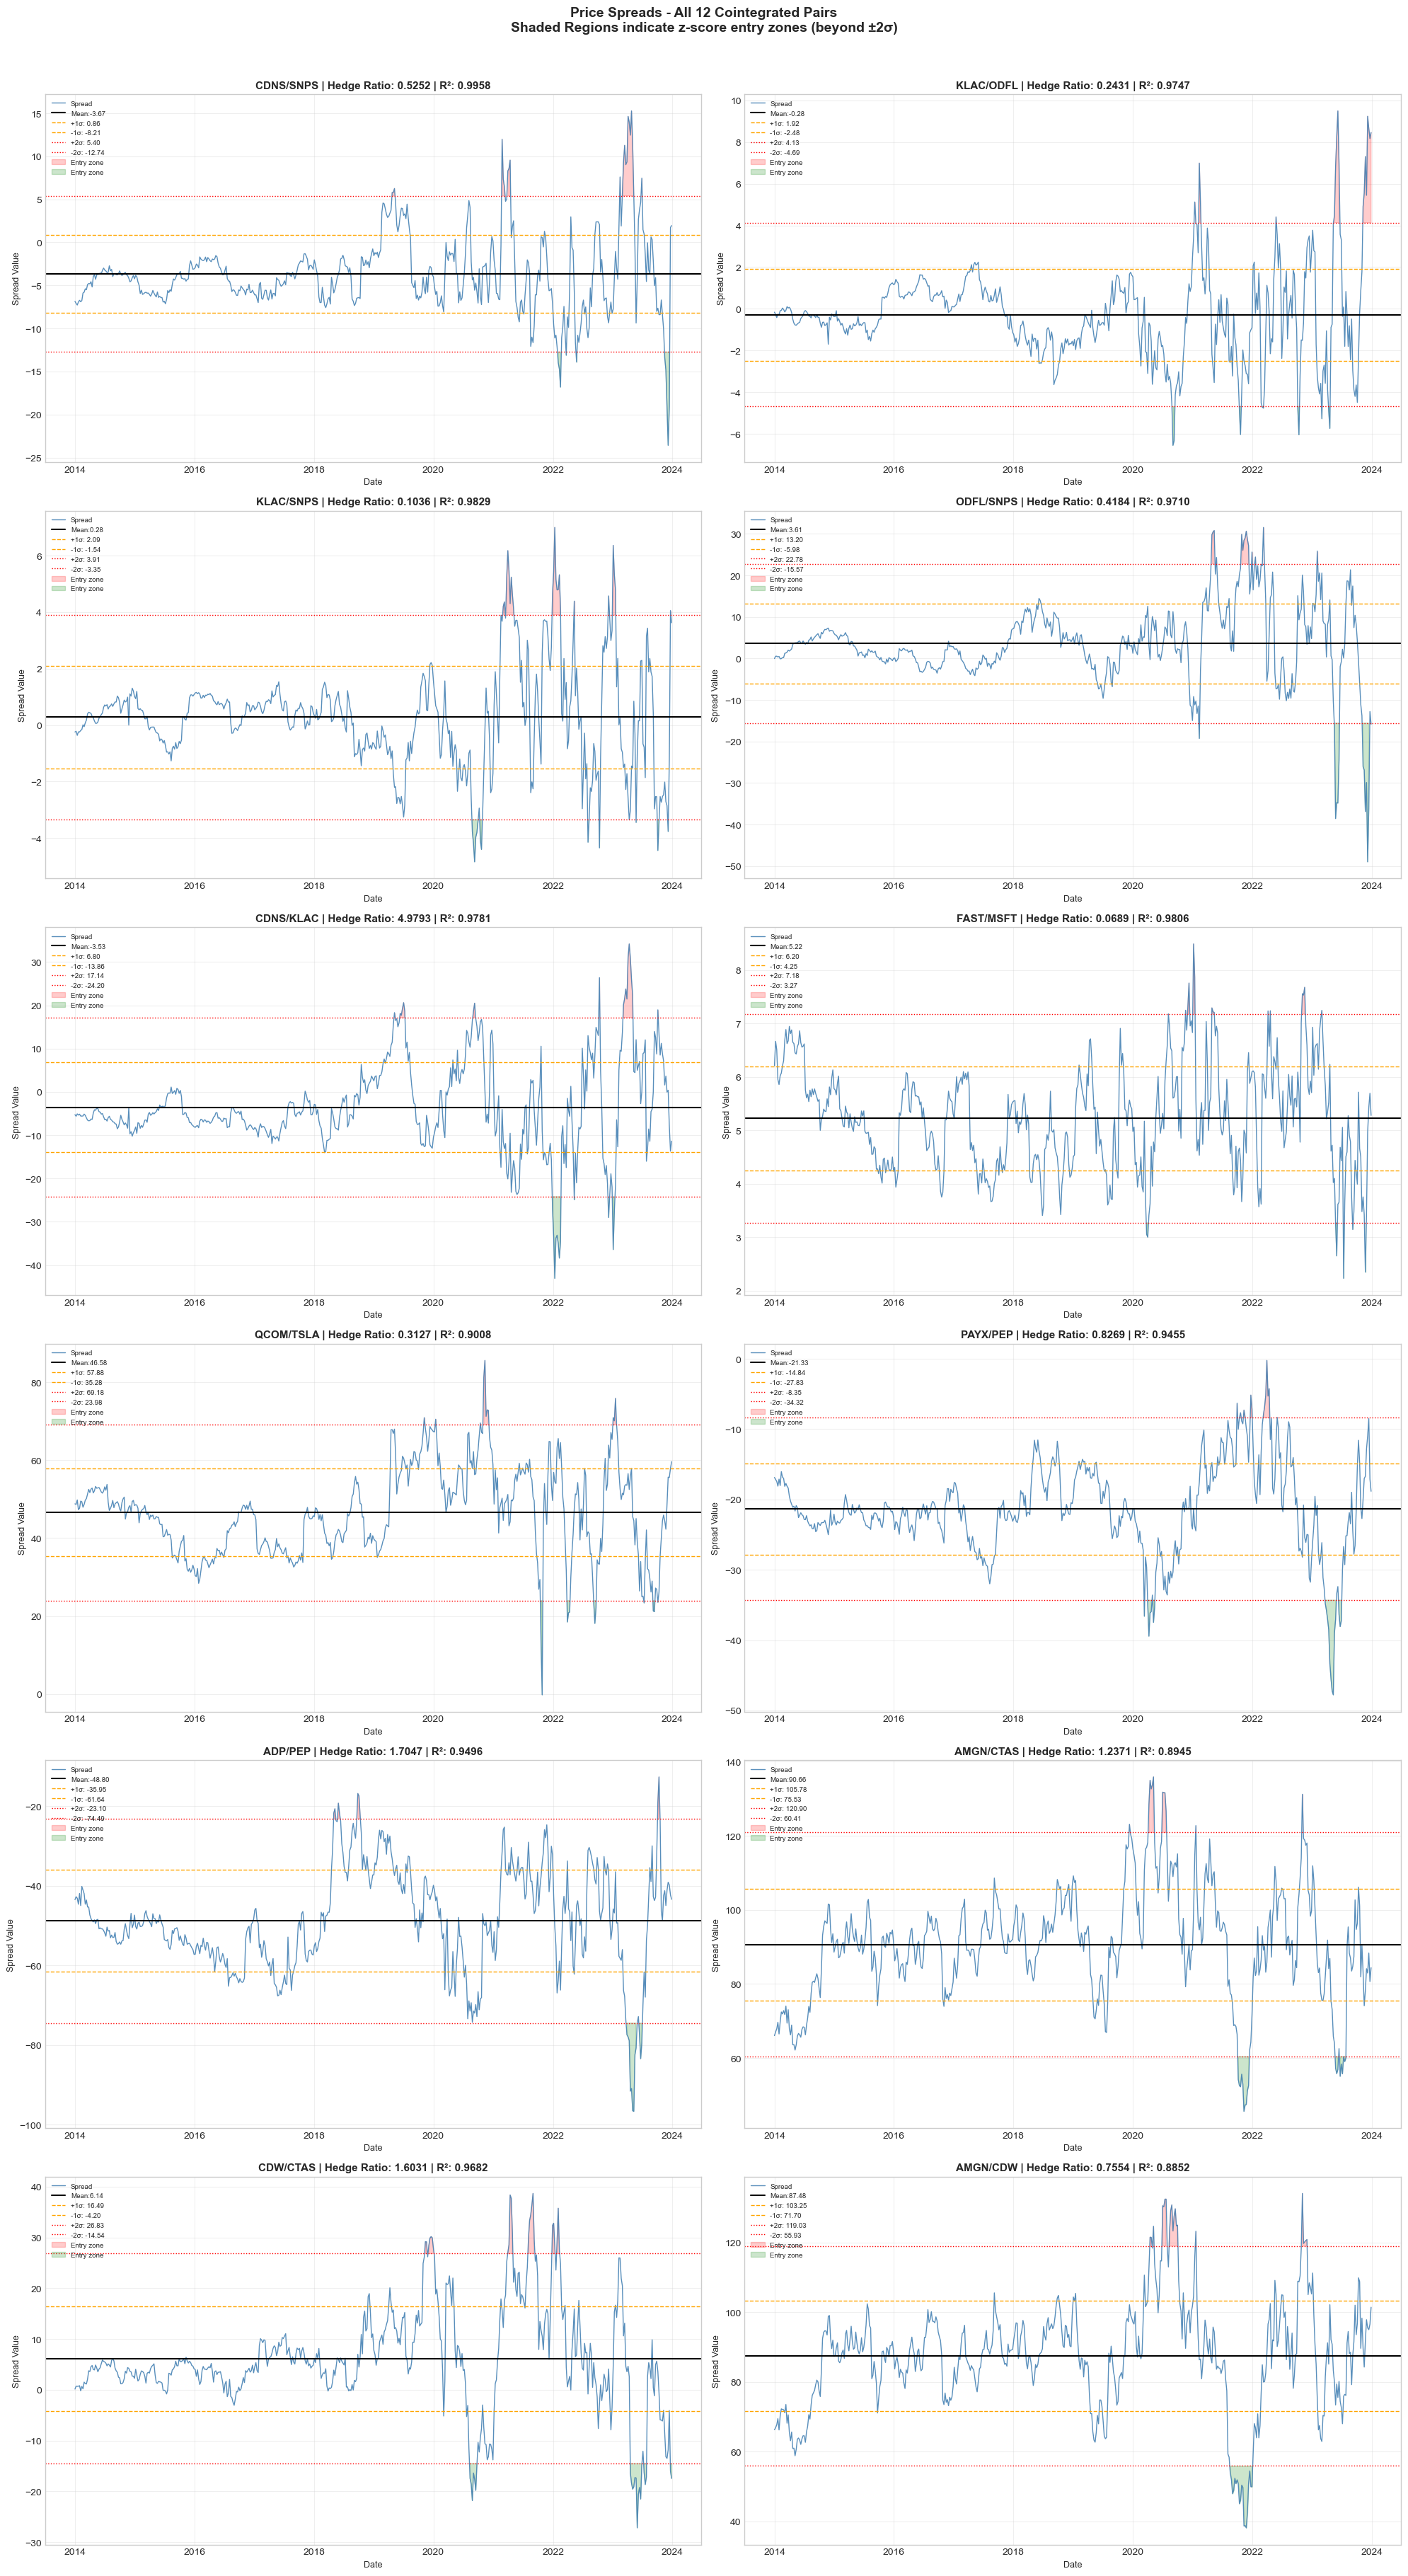

Spread visualization saved to spread_all_pairs.png


In [18]:
# Visualizing spread for all 12 pairs
print('Generating spread visualizations for all 12 pairs...')

fig, axes = plt.subplots(6,2, figsize=(20,36))
axes = axes.flatten()

for idx, (pair_name, data) in enumerate(spread_data.items()):
    ax = axes[idx]
    spread = data['spread']
    t1 = data['ticker1']
    t2 = data['ticker2']
    hedge_ratio = data['hedge_ratio']
    r_squared = data['r_squared']

    # Computing spread statistics 
    spread_mean = spread.mean()
    spread_std = spread.std()

    # Plotting spread
    ax.plot(spread.index, spread.values, 
            color='steelblue', linewidth=1.0, alpha=0.9, label='Spread')

    # Plotting mean line
    ax.axhline(y=spread_mean, color='black',
               linewidth=1.5, linestyle='-', label=f'Mean:{spread_mean:.2f}')

    # Plotting +/- 1 std bands 
    ax.axhline(y=spread_mean + spread_std, color='orange',
               linewidth=1.0, linestyle='--', label=f'+1σ: {spread_mean + spread_std:.2f}')
    ax.axhline(y=spread_mean - spread_std, color='orange',
               linewidth=1.0, linestyle='--', label=f'-1σ: {spread_mean - spread_std:.2f}')


     # Plotting +/- 2 std bands 
    ax.axhline(y=spread_mean + 2*spread_std, color='red',
               linewidth=1.0, linestyle=':', label=f'+2σ: {spread_mean + 2*spread_std:.2f}')
    ax.axhline(y=spread_mean - 2*spread_std, color='red',
               linewidth=1.0, linestyle=':', label=f'-2σ: {spread_mean - 2*spread_std:.2f}')

    # Shading regions beyond 2 std
    ax.fill_between(spread.index, spread_mean + 2*spread_std,
                    spread.values,
                    where=(spread.values > spread_mean + 2*spread_std),
                    alpha=0.2, color='red',label='Entry zone')
    ax.fill_between(spread.index, spread_mean - 2*spread_std, 
                    spread.values,
                    where=(spread.values < spread_mean - 2*spread_std), 
                    alpha=0.2, color='green', label='Entry zone')

    # Formatting
    ax.set_title(
        f'{t1}/{t2} | Hedge Ratio: {hedge_ratio:.4f} | R²: {r_squared:.4f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Spread Value', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle(
    'Price Spreads - All 12 Cointegrated Pairs\n'
    'Shaded Regions indicate z-score entry zones (beyond ±2σ)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('spread_all_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Spread visualization saved to spread_all_pairs.png')   

Z-scores computed for all pairs.
First valid z-score date: 2014-12-24
(First 52 weeks used as burn-in for rolling window)



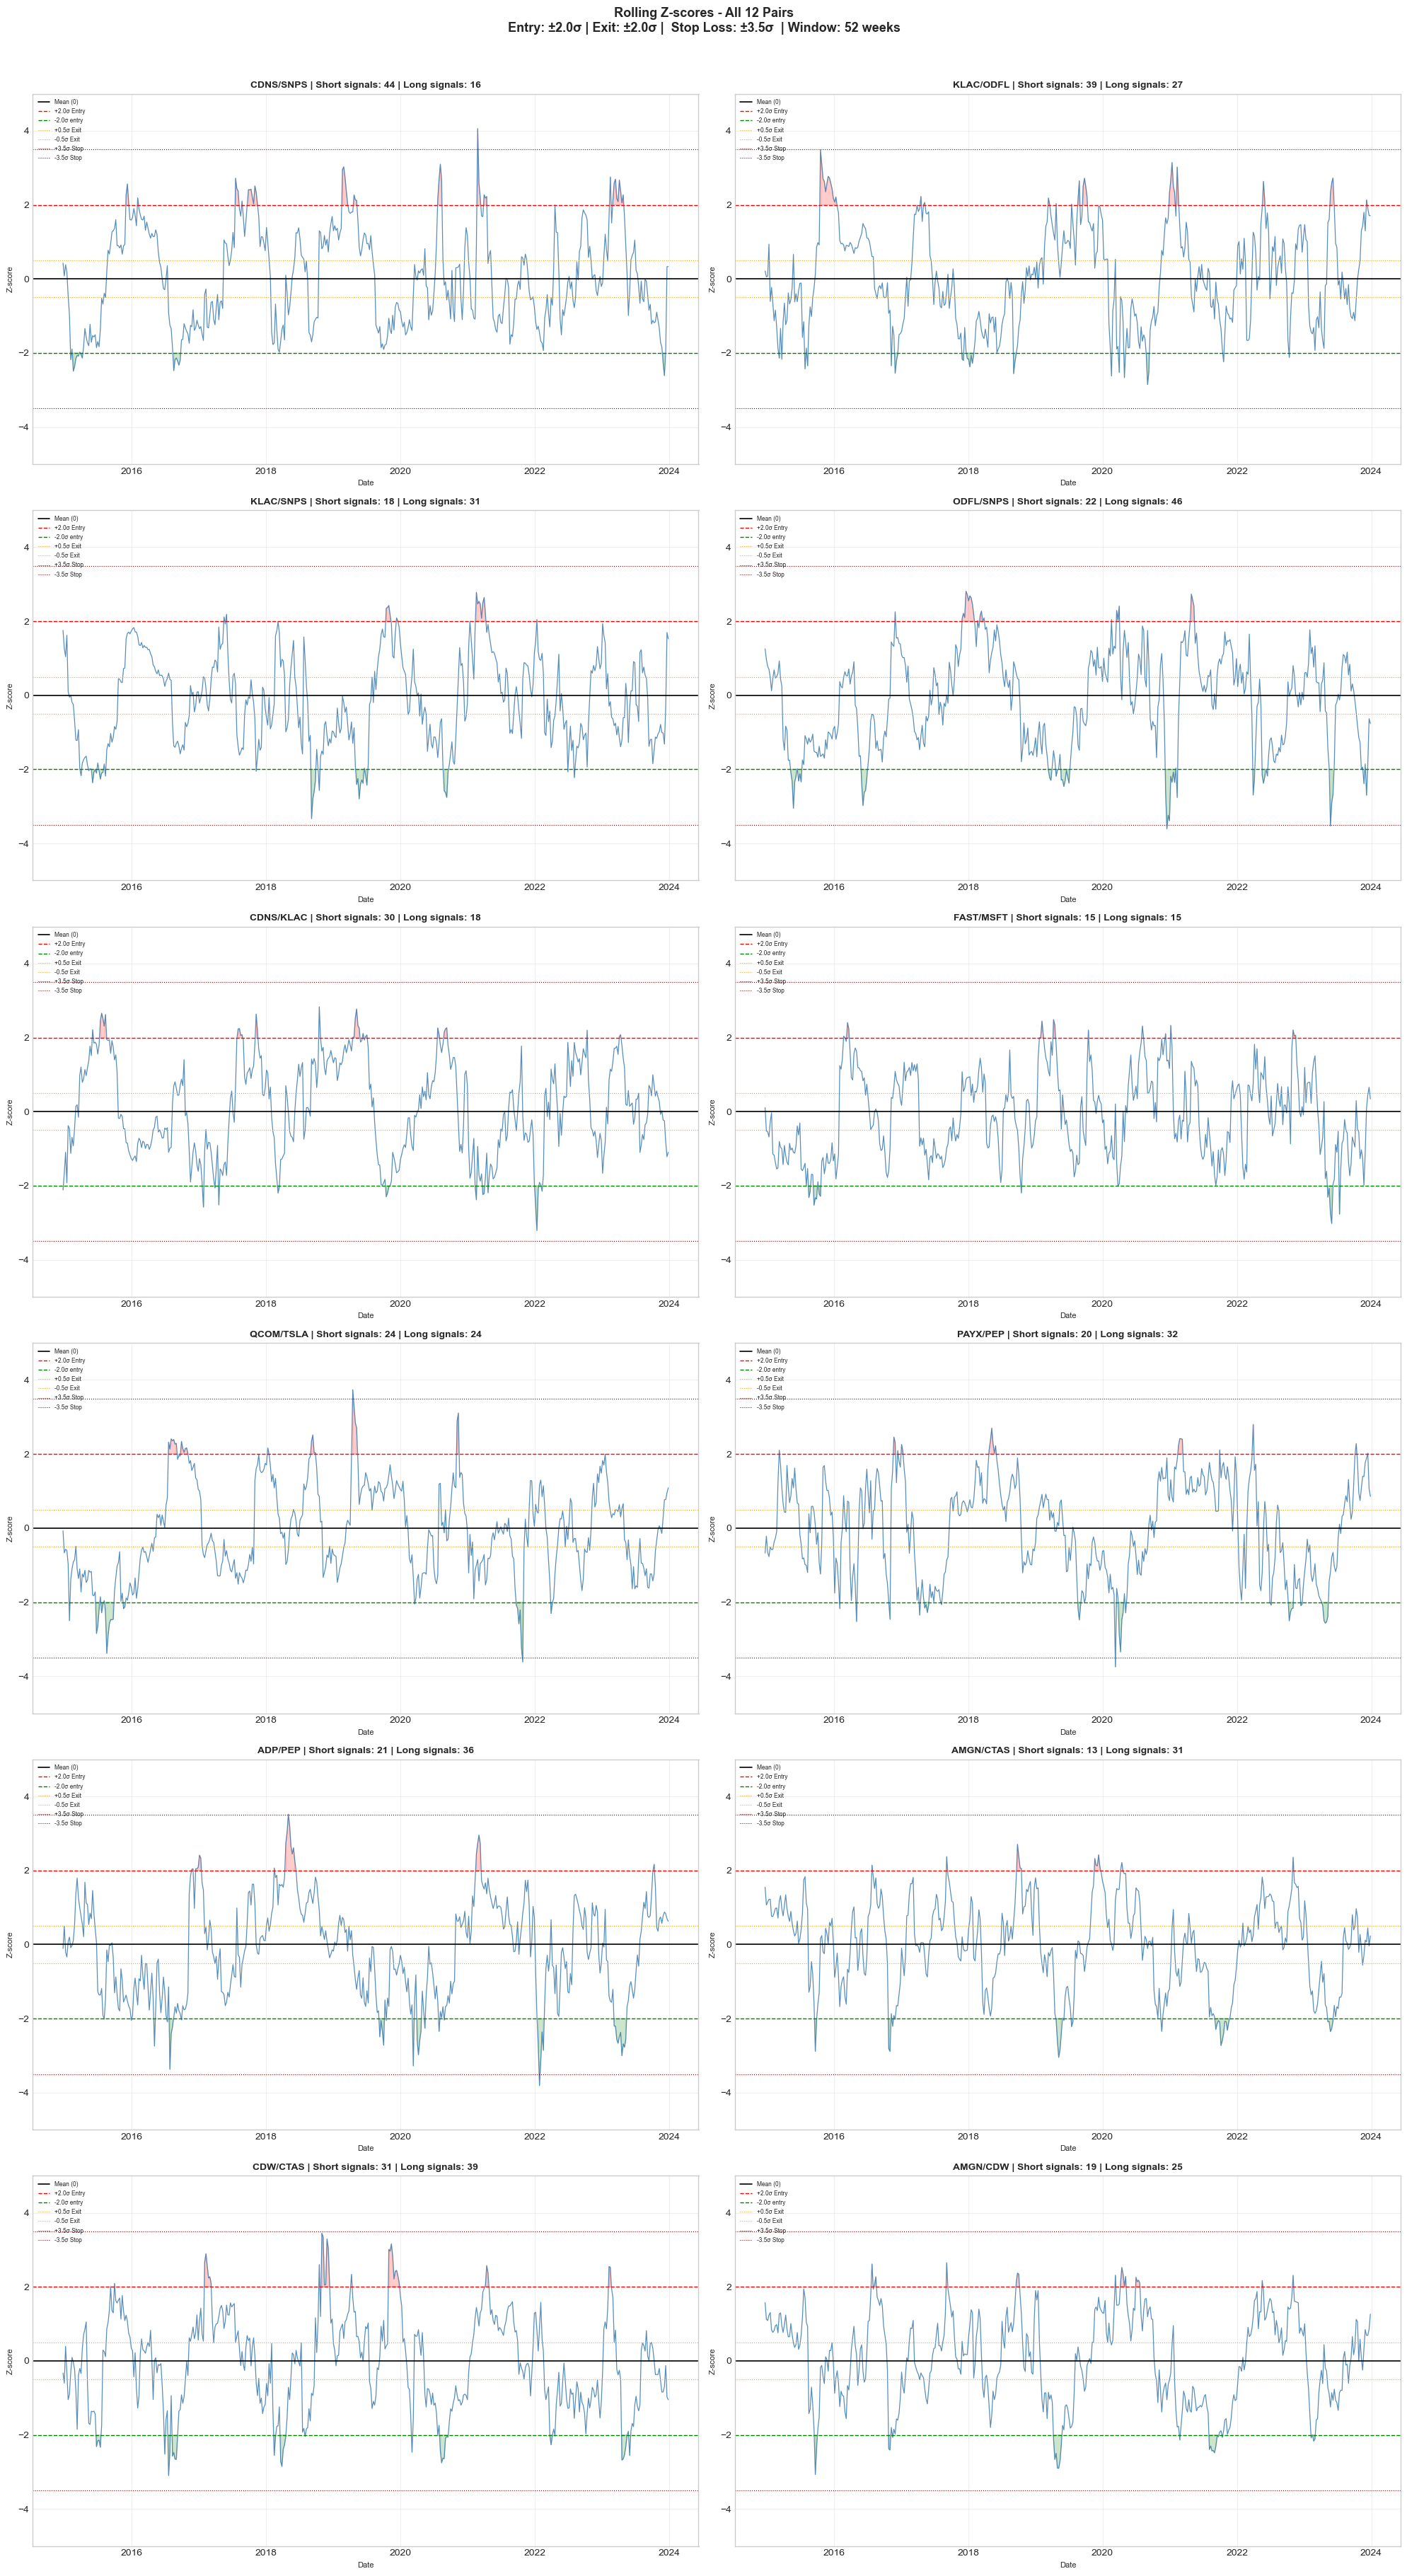

Z-score visualization saved to zscores_all_pairs.png


In [23]:
# Computing Z-score for all 12 pairs
def compute_score(spread, window=52):
    """
    Converts a spread series into a rolling z-score

    Z-score = (spread - rolling_mean) / rolling_std

    A z-score of +2 means the spread is 2 standard deviations above 
    its rolling mean - a signal to short the spread.
    
    A z-score of -2 means the spread is 2 standard deviations below 
    its rolling mean - a signal to long the spread.
    """
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    zscore = (spread - rolling_mean) / rolling_std
    return zscore, rolling_mean, rolling_std

ZSCORE_WINDOW = 52
ENTRY_THRESHOLD = 2.0    # Enter trade when |z-score| crosses 2.0
EXIT_THRESHOLD = 0.5     # Exit trade when |z-score| reverts back to 0.5
STOP_LOSS = 3.5          # Stop loss when |z-score| exceeds 3.5

zscore_data = {}

for pair_name, data in spread_data.items():
    spread = data['spread']
    zscore, rolling_mean, rolling_std = compute_score(spread, window=ZSCORE_WINDOW)

    zscore_data[pair_name] = {
        'zscore': zscore, 
        'rolling_mean': rolling_mean,
        'rolling_std': rolling_std,
        'spread': spread
    }

print("Z-scores computed for all pairs.")
print(f"First valid z-score date: "
      f"{zscore_data['CDNS/SNPS']['zscore'].dropna().index[0].date()}")
print(f"(First {ZSCORE_WINDOW} weeks used as burn-in for rolling window)\n")

# Visualizing z-scores for all 12 pairs
fig, axes = plt.subplots(6,2, figsize=(20,36))
axes = axes.flatten()

for idx, (pair_name, data) in enumerate(zscore_data.items()):
    ax = axes[idx]
    zscore = data['zscore'].dropna()

    # Plotting z-score
    ax.plot(zscore.index, zscore.values,
            color='steelblue', linewidth=0.9, alpha=0.9)

    # Plotting threshold lines
    ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-', label='Mean (0)')
    ax.axhline(y=ENTRY_THRESHOLD, color='red', linewidth=1.0,
               linestyle='--', label=f'+{ENTRY_THRESHOLD}σ Entry')
    ax.axhline(y=-ENTRY_THRESHOLD, color='green', linewidth=1.0,
               linestyle='--', label=f'-{ENTRY_THRESHOLD}σ entry')
    ax.axhline(y=EXIT_THRESHOLD, color='orange', linewidth=0.8,
               linestyle=':', label=f'+{EXIT_THRESHOLD}σ Exit')
    ax.axhline(y=-EXIT_THRESHOLD, color='orange', linewidth=0.8,
               linestyle=':', label=f'-{EXIT_THRESHOLD}σ Exit')
    ax.axhline(y=STOP_LOSS, color='darkred', linewidth=0.8,
               linestyle=':', label=f'+{STOP_LOSS}σ Stop')
    ax.axhline(y=-STOP_LOSS, color='darkred', linewidth=0.8,
               linestyle=':', label=f'-{STOP_LOSS}σ Stop')

    # Shading entry zones
    ax.fill_between(zscore.index, ENTRY_THRESHOLD, zscore.values,
                    where=(zscore.values > ENTRY_THRESHOLD),
                    alpha=0.2, color='red')
    ax.fill_between(zscore.index, -ENTRY_THRESHOLD, zscore.values,
                    where=(zscore.values < -ENTRY_THRESHOLD),
                    alpha=0.2, color='green')

    # Counting Signals
    n_short = (zscore > ENTRY_THRESHOLD).sum()
    n_long = (zscore < -ENTRY_THRESHOLD).sum()

    ax.set_title(
        f'{pair_name} | Short signals: {n_short} | Long signals: {n_long}',
        fontsize=10, fontweight= 'bold'
    )
    ax.set_xlabel('Date', fontsize=8)
    ax.set_ylabel('Z-score', fontsize=8)
    ax.legend(fontsize=6, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.set_ylim(-5,5)

plt.suptitle(
    'Rolling Z-scores - All 12 Pairs\n'
    f'Entry: ±{ENTRY_THRESHOLD}σ | Exit: ±{ENTRY_THRESHOLD}σ '
    f'|  Stop Loss: ±{STOP_LOSS}σ  | Window: {ZSCORE_WINDOW} weeks',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('zscores_all_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Z-score visualization saved to zscores_all_pairs.png')   

In [29]:
def backtest_pair(pair_name, spread_data, zscore_data,
                  entry_threshold=ENTRY_THRESHOLD,
                  exit_threshold=EXIT_THRESHOLD,
                  stop_loss=STOP_LOSS):
    """
    Backtesting a simple mean-reversion pairs trading stategy

    Position conventions:
    +1 = Long spread (long ticker1, short ticker2) - entered when z < -entry
    -1 = Short spread (short ticker1, long ticker2) - entered when z > entry
     0 = Flat - no position

     Returns a DataFrame with weekly positions, spread PnL and cumulative returns.
     """

    spread = spread_data[pair_name]['spread']
    zscore = zscore_data[pair_name]['zscore']

    # Aligning on shared non-NaN dates
    combined = pd.concat([spread, zscore], axis=1).dropna()
    combined.columns = ['spread', 'zscore']

    # Initializing tracking variables
    position      = 0
    entry_zscore  = None
    positions     = []
    spread_values = []
    pnl           = []    # weekly PnL

    prev_spread = None    

    # Walk forward through time
    for i in range(len(combined)):
        row            = combined.iloc[i]
        z              = float(row['zscore'])
        s              = float(row['spread'])

        weekly_pnl = 0.0

        if position != 0 and prev_spread is not None:
            # Calculating PnL from holding position for one week
            spread_change = s - prev_spread
            weekly_pnl    = position * spread_change

        # Exit Logic (check before entering a trade)
        if position == 1:
            # Long spread - exit when z reverts above -exit_threshold
            if z >= -exit_threshold or z <= -stop_loss:
                position     = 0
                entry_zscore = None

        elif position == -1:
            # Short spread - exit when z reverts below + exit_threshold
            if z <= exit_threshold or z >= stop_loss:
                position     = 0
                entry_zscore = None

        # Entry Logic
        if position == 0:
            if z <= -entry_threshold:
                # Spread unusually low - go long spread
                position     = 1
                entry_zscore = z

            elif z >= entry_threshold:
                # Spread unusually high - go short spread
                position         = -1 
                entry_zscore     = z

        # Recording State
        positions.append(position)
        spread_values.append(s)
        pnl.append(weekly_pnl)
        prev_spread = s

    # Building results DataFrame
    results = pd.DataFrame({
        'spread':      spread_values,
        'zscore':      combined['zscore'].values,
        'positions':   positions,
        'weekly_pnl':  pnl
    }, index=combined.index)

    results['cumulative_pnl'] = results['weekly_pnl'].cumsum()

    return results

# Running backtests for all 12 pairs
print('Running backtest for all 12 pairs...')
print(f"Entry:  ±{ENTRY_THRESHOLD}σ  |  "
      f"Exit:  ±{EXIT_THRESHOLD}σ   |  "
      f"Stop Loss: ±{STOP_LOSS}σ\n")

backtest_results = {}

for pair_name in spread_data.keys():
    backtest_results[pair_name] = backtest_pair(
        pair_name, spread_data, zscore_data
    )

print('Backtest complete for all 12 pairs.')
print(f'\nSample output for CDNS/SNPS (first 5 rows with positions):')
cdns_snps = backtest_results['CDNS/SNPS']
print(cdns_snps[cdns_snps['positions'] != 0].head())   

Running backtest for all 12 pairs...
Entry:  ±2.0σ  |  Exit:  ±0.5σ   |  Stop Loss: ±3.5σ

Backtest complete for all 12 pairs.

Sample output for CDNS/SNPS (first 5 rows with positions):
            spread  zscore  positions  weekly_pnl  cumulative_pnl
Date                                                             
2015-02-04 -5.9362 -2.1813          1      0.0000          0.0000
2015-02-11 -5.5566 -1.8925          1      0.3796          0.3796
2015-02-18 -6.0450 -2.4912          1     -0.4884         -0.1088
2015-02-25 -5.9656 -2.3630          1      0.0794         -0.0294
2015-03-04 -5.8404 -2.1497          1      0.1253          0.0958
